# VVIQ-16 Imagery Study

Reproduces the **VVIQ-16 response distribution** figure using PsychScanner:

- Task: [Vividness of Visual Imagery Questionnaire](https://en.wikipedia.org/wiki/Vividness_of_Visual_Imagery_Questionnaire), 16 items across 4 scenes
- Parser: `DefaultLiteralVivid15` (1–5 vividness scale)
- Two memory conditions: `SingleTurn` (No Memory) vs `Convo` (Conversation Memory)
- 5 simulations per condition (`nsim=5`)

The output figure shows how response distributions differ across memory conditions.

## 1. Setup

In [14]:
import os
from dotenv import load_dotenv
# https://www.youtube.com/watch?v=PYuTzLswn_Y

load_dotenv()

API_KEY = os.getenv("GROQ_KEY")


In [15]:
from pathlib import Path
import matplotlib.pyplot as plt
import polars as pl

from psychscanner import ExpCard, ExpCardInit, ScannerModel, to_csv, concat_csv

# ── backend ──────────────────────────────────────────────────────────────────
# Change these two lines if you don't use Ollama.
# Any model that supports structured output (json_schema) will work.
MODEL_NAME   = 'smollm2:360m-instruct-fp16'#"openai/gpt-oss-120b"#
MODEL_FAMILY = 'ollama'#"groq"#

TASK_FILE   = Path.cwd() / "tasks" / "vviq16.json"
PROJECT_DIR = Path.cwd() / "_vviq16_study"
PROJECT_DIR.mkdir(exist_ok=True)
print(f"Outputs → {PROJECT_DIR}")

Outputs → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_vviq16_study


## 2. Task overview

The VVIQ-16 presents **four imagery scenes**, each with four aspects to rate:

| Scene | Items | Topic |
|-------|-------|-------|
| S1 | 1–4  | A familiar person |
| S2 | 5–8  | A rising sun |
| S3 | 9–12 | A shop front |
| S4 | 13–16| A country landscape |

Ratings use the **`DefaultLiteralVivid15`** parser (1 = no image at all, 5 = perfectly vivid).

## 3. Run experiments

In [16]:
# ── Condition 1: No Memory (SingleTurn) ──────────────────────────────────────
card_st = ExpCardInit()
card_st.proj_dir     = PROJECT_DIR
card_st.projectname  = "vviq16study"
card_st.model        = MODEL_NAME
card_st.family       = MODEL_FAMILY
#card_st.parameters   =  {'api_key': API_KEY}
card_st.task_file    = TASK_FILE
card_st.parser       = "1"          # read DefaultLiteralVivid15 from task JSON
card_st.memory       = "SingleTurn" # no memory between trials
card_st.cogtype      = "no"
card_st.nsim         = 5
card_st.tunnel_status = "0"

scanner_st = ScannerModel(expcard=ExpCard(card_st))
results_st = scanner_st.run()
print(f"SingleTurn: {len(results_st)} simulations × {len(results_st[0])} trials")

----<PROJECT AND DATA ROOT DIRECTORY>----


	Project root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_vviq16_study
	Simulation data root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_vviq16_study/vviq16study/vviq16/ollama_smollm2:360m-instruct-fp16_SingleTurn
----<>----
--<chat model>-- model='smollm2:360m-instruct-fp16'


2026-05-07 07:08:06.738 | CRITICAL | psychscanner.session_tunnel.session_tunnel:create_tunnel:152 - BEGIN


TOTAL RUNS: 5	RESUME IDX: None
----<>---- task running


16it [00:25,  1.58s/it]
2026-05-07 07:08:32.113 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


...

----<scanned runs>---- i = 3
----<>---- task running


16it [00:16,  1.04s/it]
2026-05-07 07:09:45.444 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 4


2026-05-07 07:09:45.450 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END


SingleTurn: 5 simulations × 16 trials


In [17]:
# ── Condition 2: Conversation Memory (Convo) ─────────────────────────────────
card_cv = ExpCardInit()
card_cv.proj_dir     = PROJECT_DIR
card_cv.projectname  = "vviq16study"
card_cv.model        = MODEL_NAME
card_cv.family       = MODEL_FAMILY
#card_cv.parameters   = {'api_key': API_KEY}
card_cv.task_file    = TASK_FILE
card_cv.parser       = "1"
card_cv.memory       = "Convo"      # full conversation context retained
card_cv.cogtype      = "no"
card_cv.nsim         = 5
card_cv.tunnel_status = "0"

scanner_cv = ScannerModel(expcard=ExpCard(card_cv))
results_cv = scanner_cv.run()
print(f"Convo: {len(results_cv)} simulations × {len(results_cv[0])} trials")

----<PROJECT AND DATA ROOT DIRECTORY>----
	Project root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_vviq16_study


	Simulation data root dir: /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_vviq16_study/vviq16study/vviq16/ollama_smollm2:360m-instruct-fp16_Convo
----<>----
--<chat model>-- model='smollm2:360m-instruct-fp16'


2026-05-07 07:09:45.861 | CRITICAL | psychscanner.session_tunnel.session_tunnel:create_tunnel:152 - BEGIN


TOTAL RUNS: 5	RESUME IDX: None
----<>---- task running


16it [00:30,  1.93s/it]
2026-05-07 07:10:16.789 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


...

----<scanned runs>---- i = 3
----<>---- task running


16it [00:44,  2.77s/it]
2026-05-07 07:13:17.913 | INFO     | psychscanner.session_tunnel.session_tunnel:scan_checkpoint:184 - scan-checkpoint


----<scanned runs>---- i = 4


2026-05-07 07:13:17.935 | CRITICAL | psychscanner.session_tunnel.session_tunnel:end_checkpoint:163 - END


Convo: 5 simulations × 16 trials


## 4. Export to CSV

In [20]:
# Individual CSVs per condition
df_st = to_csv(scanner_st, path=PROJECT_DIR / "vviq16_singleturn.csv")
df_cv = to_csv(scanner_cv, path=PROJECT_DIR / "vviq16_convo.csv")

# Combined CSV for downstream analysis
df_all = to_csv([scanner_st, scanner_cv],
                path=PROJECT_DIR / "vviq16_combined.csv",
                combined=True)

print(f"\nCombined: {df_all.shape[0]} rows × {df_all.shape[1]} columns")
#df_all.select(["model", "memory", "trcode", "trial_idx", "resp_Vividness"]).head(6)

Saved 80 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_vviq16_study/vviq16_singleturn.csv
Saved 80 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_vviq16_study/vviq16_convo.csv
Saved 160 rows from 2 source(s) → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_vviq16_study/vviq16_combined.csv

Combined: 160 rows × 19 columns


## 5. Reproduce the figure

Each dot is one simulation's vividness rating for a trial. With 5 simulations × 16 trials = 80 data points per panel.

ColumnNotFoundError: "resp_Vividness" not found

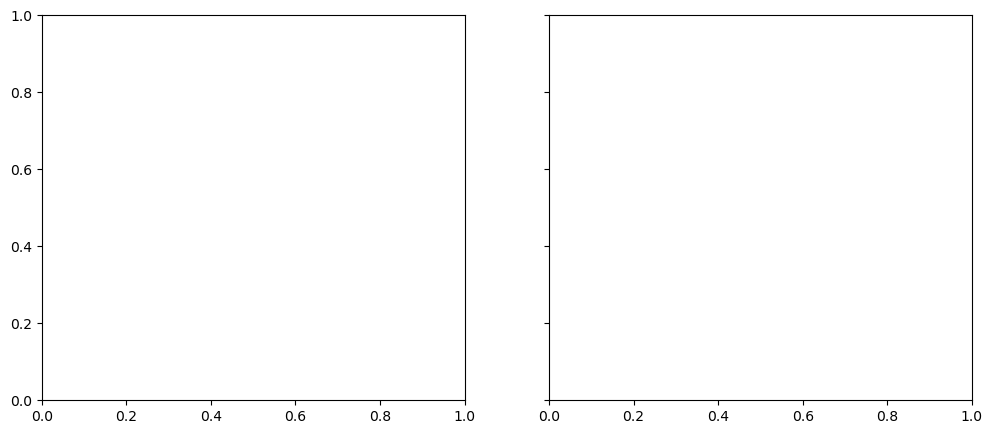

In [21]:
def _trial_number(df: pl.DataFrame) -> list[int]:
    """Map trial_idx (0-based) to trial number (1-based)."""
    return (df["trial_idx"] + 1).to_list()

def _vividness(df: pl.DataFrame) -> list[float]:
    return df["resp_Vividness"].to_list()

fig, (ax_st, ax_cv) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# ── Left: No Memory ──────────────────────────────────────────────────────────
ax_st.scatter(_trial_number(df_st), _vividness(df_st),
              color="steelblue", s=60, alpha=0.85, zorder=3)
ax_st.set_title("No Memory", fontsize=14)
ax_st.set_xlabel("Trial Number", fontsize=12)
ax_st.set_ylabel("Rating response (1 to 5)", fontsize=12)
ax_st.set_xlim(0, 17)
ax_st.set_xticks(range(2, 17, 2))
ax_st.set_ylim(0.5, 5.5)
ax_st.set_yticks([1, 2, 3, 4, 5])
ax_st.grid(axis="y", linestyle="--", alpha=0.4)

# ── Right: Conversation Memory ────────────────────────────────────────────────
ax_cv.scatter(_trial_number(df_cv), _vividness(df_cv),
              color="gray", s=60, alpha=0.85, zorder=3)
ax_cv.set_title("Conversation Memory", fontsize=14)
ax_cv.set_xlabel("Trial Number", fontsize=12)
ax_cv.set_xlim(0, 17)
ax_cv.set_xticks(range(2, 17, 2))
ax_cv.set_ylim(0.5, 5.5)
ax_cv.set_yticks([1, 2, 3, 4, 5])
ax_cv.grid(axis="y", linestyle="--", alpha=0.4)

model_label = MODEL_NAME.replace(":", " ")
fig.suptitle(
    f"VVIQ-16 (Imagination Questionnaire) response distribution in {card_st.nsim} simulations",
    fontsize=13, y=1.02
)
plt.tight_layout()
fig.savefig(PROJECT_DIR / "vviq16_figure.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {PROJECT_DIR / 'vviq16_figure.png'}")

## 6. Reload from disk and re-plot

Demonstrates loading the saved CSVs (or the `.psyscan` archive) without re-running the model.

In [22]:
# Load from individual CSVs
df_st_reload = pl.read_csv(PROJECT_DIR / "vviq16_singleturn.csv")
df_cv_reload = pl.read_csv(PROJECT_DIR / "vviq16_convo.csv")
print("Reloaded from CSV:")
print(f"  SingleTurn: {df_st_reload.shape}")
print(f"  Convo:      {df_cv_reload.shape}")

# Or reload directly from the .psyscan archive using to_csv
data_dir = PROJECT_DIR / "vviq16_study"
df_from_psyscan = to_csv(data_dir)
print(f"\nReloaded from .psyscan archive: {df_from_psyscan.shape}")

Reloaded from CSV:
  SingleTurn: (80, 19)
  Convo:      (80, 19)
Saved 96 rows → /Users/saurabhext/Documents/PSYCHSCANNER/psychscanner/examples/_vviq16_study/vviq16_study/vviq16_study_vviq16_openai-gpt-oss-120b_SingleTurn_20260507_071706.csv

Reloaded from .psyscan archive: (96, 20)


## Summary

| Step | Code |
|------|------|
| Define task | `examples/tasks/vviq16.json` — 16 items, `parser: DefaultLiteralVivid15` |
| Run No Memory | `card.memory = "SingleTurn"`, `nsim=5` |
| Run Convo Memory | `card.memory = "Convo"`, `nsim=5` |
| Export CSVs | `to_csv(scanner)` and `to_csv([...], combined=True)` |
| Reload | `to_csv(data_dir)` or `pl.read_csv(...)` |

The `Convo` condition carries the full conversation history across the 16 trials, so the model's ratings can be influenced by its own earlier responses — a property not present in `SingleTurn`.